<a href="https://colab.research.google.com/github/MrChooey/Diabetes_Readmission/blob/main/models/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os, random

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

USE_GPU = False  # set True if you want to use GPU for XGBoost
TREE_METHOD = "gpu_hist" if USE_GPU else "hist"

print("TREE_METHOD:", TREE_METHOD)

TREE_METHOD: hist


In [6]:
from google.colab import drive
drive.mount('/content/drive')

# === CONFIG ===
PATH_TO_TRAIN_CSV = "/content/drive/MyDrive/diabetes_readmission/Dataset/training.csv"
TARGET_COL = "readmitted"

df = pd.read_csv(PATH_TO_TRAIN_CSV)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int).values

print("Train shape:", df.shape)
print("Positive class ratio:", y.mean().round(4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (71219, 105)
Positive class ratio: 0.1116


In [7]:
def summarize_fold(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return dict(
        accuracy = accuracy_score(y_true, y_pred),
        precision= precision_score(y_true, y_pred, zero_division=0),
        recall   = recall_score(y_true, y_pred, zero_division=0),
        f1       = f1_score(y_true, y_pred, zero_division=0),
        auc_roc  = roc_auc_score(y_true, y_prob)
    )


In [8]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = np.zeros(len(X), dtype=np.float32)
oof_pred  = np.zeros(len(X), dtype=np.int32)
fold_metrics = []

print("Beginning 5-fold CV for XGBoost...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[va_idx], y[va_idx]

    sm = SMOTE(random_state=SEED)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

    xgb = XGBClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method=TREE_METHOD,
        early_stopping_rounds=100,
        random_state=SEED,
        n_jobs=-1
    )

    xgb.fit(
        X_tr_res, y_tr_res,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    va_prob = xgb.predict_proba(X_va)[:, 1]
    va_pred = (va_prob >= 0.5).astype(int)

    oof_proba[va_idx] = va_prob
    oof_pred[va_idx]  = va_pred

    m = summarize_fold(y_va, va_prob, thr=0.5)
    fold_metrics.append({"fold": fold, **m})
    print(f"Fold {fold}: Acc={m['accuracy']:.4f} | Pre={m['precision']:.4f} | "
          f"Rec={m['recall']:.4f} | F1={m['f1']:.4f} | AUC={m['auc_roc']:.4f}")

print("\nDone.")

Beginning 5-fold CV for XGBoost...
Fold 1: Acc=0.8882 | Pre=0.4872 | Rec=0.0478 | F1=0.0871 | AUC=0.6544
Fold 2: Acc=0.8866 | Pre=0.4188 | Rec=0.0422 | F1=0.0766 | AUC=0.6536
Fold 3: Acc=0.8862 | Pre=0.4059 | Rec=0.0434 | F1=0.0785 | AUC=0.6443
Fold 4: Acc=0.8856 | Pre=0.3886 | Rec=0.0428 | F1=0.0771 | AUC=0.6524
Fold 5: Acc=0.8853 | Pre=0.3706 | Rec=0.0396 | F1=0.0716 | AUC=0.6435

Done.


In [9]:
metrics_df = pd.DataFrame(fold_metrics)
display(metrics_df)

avg = metrics_df[["accuracy","precision","recall","f1","auc_roc"]].mean()
std = metrics_df[["accuracy","precision","recall","f1","auc_roc"]].std()

print("\n=== Averaged 5-Fold Performance (XGBoost) ===")
for k in ["accuracy","precision","recall","f1","auc_roc"]:
    print(f"{k.upper():9s}: {avg[k]:.4f} ± {std[k]:.4f}")

level1_xgb = pd.DataFrame({
    "xgb_oof_proba": oof_proba,
    "xgb_oof_pred":  oof_pred
}, index=X.index)

display(level1_xgb.head())

# Save for stacking later
# SAVE_OOF = "/content/drive/MyDrive/diabetes_readmission/level1_oof_train_xgb.csv"
# level1_xgb.to_csv(SAVE_OOF, index=True)
# print("Saved XGBoost OOF features to:", SAVE_OOF)


,fold,accuracy,precision,recall,f1,auc_roc
0,1,0.888163,0.487179,0.047829,0.087106,0.654388
1,2,0.886619,0.418750,0.042165,0.076615,0.653608
2,3,0.886198,0.405882,0.043424,0.078454,0.644340
3,4,0.885636,0.388571,0.042767,0.077054,0.652394
4,5,0.885347,0.370588,0.039648,0.071632,0.643450



=== Averaged 5-Fold Performance (XGBoost) ===
ACCURACY : 0.8864 ± 0.0011
PRECISION: 0.4142 ± 0.0447
RECALL   : 0.0432 ± 0.0030
F1       : 0.0782 ± 0.0056
AUC_ROC  : 0.6496 ± 0.0053


,xgb_oof_proba,xgb_oof_pred
0,0.072980,0
1,0.255642,0
2,0.193482,0
3,0.215670,0
4,0.245720,0


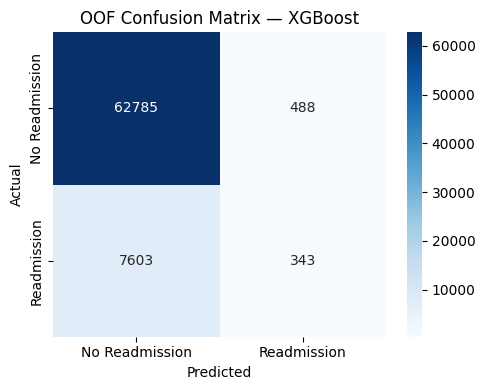

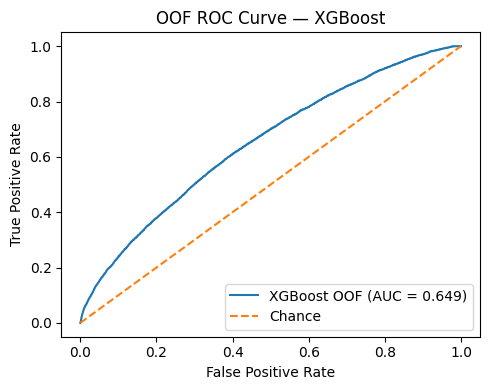

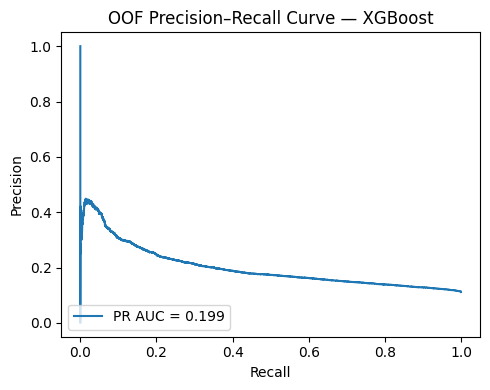

In [10]:
# Confusion Matrix
cm = confusion_matrix(y, oof_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Readmission","Readmission"],
            yticklabels=["No Readmission","Readmission"])
plt.title("OOF Confusion Matrix — XGBoost")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y, oof_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"XGBoost OOF (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve — XGBoost")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

# Precision–Recall Curve (better for imbalance)
precision, recall, _ = precision_recall_curve(y, oof_proba)
pr_auc = average_precision_score(y, oof_proba)
plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("OOF Precision–Recall Curve — XGBoost")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()